In [408]:
# ==========================
# Import Required Libraries
# ==========================

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model Saving
import pickle

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [409]:
# Importing the dataset
Development = pd.read_csv("../Dataset/HDI.csv")

# Display first five rows
Development.head()

,HDI rank,Country,HUMAN DEVELOPMENT,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,GNI per capita rank minus HDI rank,HDI rank.1,Unnamed: 10,Unnamed: 11
0,1,Switzerland,VERY HIGH,0.962,84.0,16.5,13.9,"66,933",5,3,NaN,NaN
1,2,Norway,VERY HIGH,0.961,83.2,18.2,13.0,"64,660",6,1,NaN,NaN
2,3,Iceland,VERY HIGH,0.959,82.7,19.2,13.8,"55,782",11,2,NaN,NaN
3,4,"Hong Kong, China (SAR)",VERY HIGH,0.952,85.5,17.3,12.2,"62,607",6,4,NaN,NaN
4,5,Australia,VERY HIGH,0.951,84.5,21.1,12.7,"49,238",18,5,NaN,NaN


In [410]:
# Shape of the dataset
Development.shape

(195, 12)

In [411]:
# Dataset information
Development.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 12 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   HDI rank                                195 non-null    int64  
 1   Country                                 195 non-null    str    
 2   HUMAN DEVELOPMENT                       195 non-null    str    
 3   Human Development Index (HDI)           195 non-null    str    
 4   Life expectancy at birth                195 non-null    float64
 5   Expected years of schooling             195 non-null    str    
 6   Mean years of schooling                 195 non-null    str    
 7   Gross national income (GNI) per capita  195 non-null    str    
 8   GNI per capita rank minus HDI rank      195 non-null    str    
 9   HDI rank.1                              195 non-null    str    
 10  Unnamed: 10                             0 non-null      float64
 11  Unna

In [412]:
Development.columns = Development.columns.str.strip()

Development.columns

Index(['HDI rank', 'Country', 'HUMAN DEVELOPMENT',
       'Human Development Index (HDI)', 'Life expectancy at birth',
       'Expected years of schooling', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'GNI per capita rank minus HDI rank', 'HDI rank.1', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='str')

In [413]:
# First 20 rows
data1 = Development.head(20)

In [414]:
# Unique country values
Development["Country"].unique()

<StringArray>
[                        'Switzerland',                              'Norway',
                             'Iceland',              'Hong Kong, China (SAR)',
                           'Australia',                             'Denmark',
                              'Sweden',                             'Ireland',
                             'Germany',                         'Netherlands',
 ...
                                'Mali',                             'Burundi',
            'Central African Republic',                               'Niger',
                                'Chad',                         'South Sudan',
 'Korea (Democratic People's Rep. of)',                              'Monaco',
                               'Nauru',                             'Somalia']
Length: 195, dtype: str

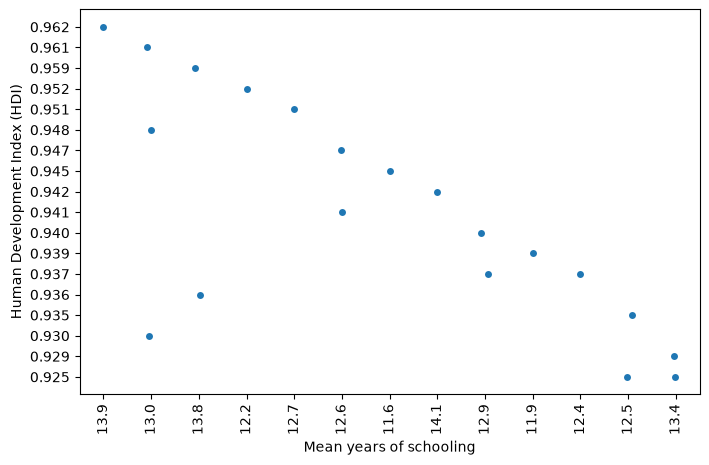

In [415]:
# Mean Years of Schooling vs HDI

plt.figure(figsize=(8,5))

sns.stripplot(
    x="Mean years of schooling",
    y="Human Development Index (HDI)",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)
plt.show()

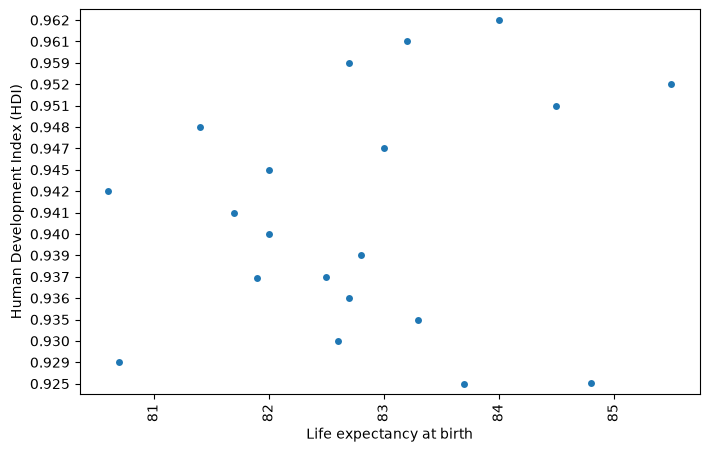

In [416]:
plt.figure(figsize=(8,5))

sns.stripplot(
    x="Life expectancy at birth",
    y="Human Development Index (HDI)",
    data=data1,
    jitter=True
)

plt.xticks(rotation=90)
plt.show()

In [417]:
import numpy as np

Development = Development.replace("..", np.nan)

In [418]:
cols = [
    "Human Development Index (HDI)",
    "Life expectancy at birth",
    "Expected years of schooling",
    "Mean years of schooling",
    "Gross national income (GNI) per capita"
]

for col in cols:
    Development[col] = pd.to_numeric(Development[col], errors="coerce")

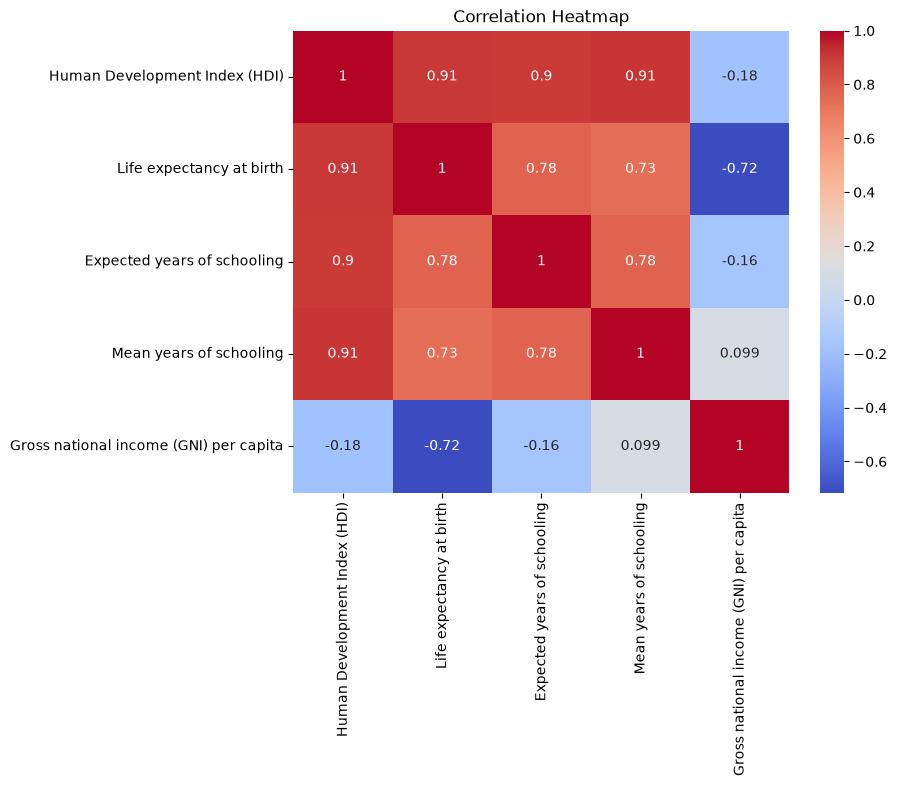

In [419]:
heat = Development[cols]

plt.figure(figsize=(8,6))

sns.heatmap(
    heat.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [420]:
# Statistical summary
Development.describe()

,HDI rank,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita,Unnamed: 10,Unnamed: 11
count,195.000000,191.000000,195.000000,193.000000,191.000000,3.0,0.0,0.0
mean,97.815385,0.720576,71.277949,13.506736,8.983770,822.0,NaN,NaN
std,56.467551,0.150661,7.746484,2.920314,3.173193,126.0,NaN,NaN
min,1.000000,0.385000,52.500000,5.500000,2.100000,732.0,NaN,NaN
25%,49.500000,0.599500,65.700000,11.500000,6.250000,750.0,NaN,NaN
50%,97.000000,0.739000,71.700000,13.400000,9.300000,768.0,NaN,NaN
75%,146.000000,0.835000,76.700000,15.600000,11.500000,867.0,NaN,NaN
max,195.000000,0.962000,85.900000,21.100000,14.100000,966.0,NaN,NaN


In [421]:
# Check missing values
Development.isnull().sum()

HDI rank                                    0
Country                                     0
HUMAN DEVELOPMENT                           0
Human Development Index (HDI)               4
Life expectancy at birth                    0
Expected years of schooling                 2
Mean years of schooling                     4
Gross national income (GNI) per capita    192
GNI per capita rank minus HDI rank          4
HDI rank.1                                  4
Unnamed: 10                               195
Unnamed: 11                               195
dtype: int64

In [422]:
# Remove empty columns
Development = Development.drop(columns=["Unnamed: 10", "Unnamed: 11"])

In [423]:
# Independent Variables (Features)

X = Development[[
    "Country",
    "Life expectancy at birth",
    "Expected years of schooling",
    "Mean years of schooling",
    "Gross national income (GNI) per capita"
]]

X = pd.DataFrame(X)

X.head()

,Country,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
0,Switzerland,84.0,16.5,13.9,NaN
1,Norway,83.2,18.2,13.0,NaN
2,Iceland,82.7,19.2,13.8,NaN
3,"Hong Kong, China (SAR)",85.5,17.3,12.2,NaN
4,Australia,84.5,21.1,12.7,NaN


In [424]:
# Dependent Variable (Target)

Y = Development["Human Development Index (HDI)"]

Y = pd.DataFrame(Y)

Y.head()

,Human Development Index (HDI)
0,0.962
1,0.961
2,0.959
3,0.952
4,0.951


In [425]:
# Check null values in X

X.isnull().sum()

Country                                     0
Life expectancy at birth                    0
Expected years of schooling                 2
Mean years of schooling                     4
Gross national income (GNI) per capita    192
dtype: int64

In [426]:
# Fill missing values

X = X.fillna(X.mean(numeric_only=True))

X.isnull().sum()

Country                                   0
Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64

In [427]:
# Train and Test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [428]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Y_train shape:", Y_train.shape)
print("Y_test shape :", Y_test.shape)

X_train shape: (175, 5)
X_test shape : (20, 5)
Y_train shape: (175, 1)
Y_test shape : (20, 1)


In [429]:
# Remove the Country column

X = X.drop("Country", axis=1)

In [430]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [431]:
# Create the Linear Regression model

reg = LinearRegression()

reg.fit(X_train, Y_train)

print("Model trained successfully!")

ValueError: Input y contains NaN.

In [ ]:
Y.isnull().sum()

Human Development Index (HDI)    4
dtype: int64

In [ ]:
mask = Y.notna()

X = X[mask]
Y = Y[mask]

In [ ]:
print(X.shape)
print(Y.shape)

(195, 4)
(195, 1)


In [ ]:
Y = Development["Human Development Index (HDI)"]

Y = pd.to_numeric(Y, errors="coerce")

In [ ]:
print(Y.isnull().sum())

4


In [ ]:
mask = Y.notna()

X = X.loc[mask]
Y = Y.loc[mask]

In [ ]:
print(X.shape)
print(Y.shape)

(191, 4)
(191,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, Y_train)

print("✅ Model trained successfully!")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X.isnull().sum()

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64

In [ ]:
print(X.dtypes)

Life expectancy at birth                  float64
Expected years of schooling               float64
Mean years of schooling                   float64
Gross national income (GNI) per capita    float64
dtype: object


In [ ]:
X.head()

,Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
0,84.0,16.5,13.9,822.0
1,83.2,18.2,13.0,822.0
2,82.7,19.2,13.8,822.0
3,85.5,17.3,12.2,822.0
4,84.5,21.1,12.7,822.0


In [ ]:
print(X_train.shape)
print(Y_train.shape)

(175, 4)
(175, 1)


In [ ]:
Y_train.isnull().sum()

Human Development Index (HDI)    3
dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [ ]:
print(Y_train.isnull().sum())

Human Development Index (HDI)    3
dtype: int64


In [ ]:
print(Y.isnull().sum())

Human Development Index (HDI)    4
dtype: int64


In [ ]:
# Create Y again from the original dataset
Y = Development["Human Development Index (HDI)"]

# Convert values to numeric
Y = pd.to_numeric(Y, errors="coerce")

# Check missing values
print(Y.isnull().sum())

4


In [ ]:
mask = Y.notna()

# Apply the mask to the ORIGINAL dataset
Development_clean = Development.loc[mask]

# Create X again
X = Development_clean[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita",
    ]
]

# Convert X to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Create Y again
Y = pd.to_numeric(
    Development_clean["Human Development Index (HDI)"],
    errors="coerce"
)

print(X.shape)
print(Y.shape)
print(Y.isnull().sum())

(191, 4)
(191,)
0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, Y_train)

print("✅ Model trained successfully!")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
print(X_train.isnull().sum())

Life expectancy at birth                    0
Expected years of schooling                 0
Mean years of schooling                     0
Gross national income (GNI) per capita    168
dtype: int64


In [ ]:
print(X.isnull().sum())

Life expectancy at birth                    0
Expected years of schooling                 0
Mean years of schooling                     0
Gross national income (GNI) per capita    188
dtype: int64


In [ ]:
Development["Gross national income (GNI) per capita"] = (
    Development["Gross national income (GNI) per capita"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

Development["Gross national income (GNI) per capita"] = pd.to_numeric(
    Development["Gross national income (GNI) per capita"],
    errors="coerce"
)

In [ ]:
X = Development[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

In [ ]:
print(X.isnull().sum())

Life expectancy at birth                    0
Expected years of schooling                 2
Mean years of schooling                     4
Gross national income (GNI) per capita    192
dtype: int64


In [ ]:
Development["Gross national income (GNI) per capita"].head(20)

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: Gross national income (GNI) per capita, dtype: float64

In [ ]:
import pandas as pd

Development = pd.read_csv("../Dataset/HDI.csv")

In [ ]:
Development["Gross national income (GNI) per capita"].head(10)

0    66,933
1    64,660
2    55,782
3    62,607
4    49,238
5    60,365
6    54,489
7    76,169
8    54,534
9    55,979
Name: Gross national income (GNI) per capita, dtype: str

In [ ]:
Development["Gross national income (GNI) per capita"] = (
    Development["Gross national income (GNI) per capita"]
    .str.replace(",", "", regex=False)
)

Development["Gross national income (GNI) per capita"] = pd.to_numeric(
    Development["Gross national income (GNI) per capita"],
    errors="coerce"
)

In [ ]:
Development["Gross national income (GNI) per capita"].head()

0    66933.0
1    64660.0
2    55782.0
3    62607.0
4    49238.0
Name: Gross national income (GNI) per capita, dtype: float64

In [ ]:
Development["Gross national income (GNI) per capita"].isnull().sum()

np.int64(2)

In [ ]:
Development["Gross national income (GNI) per capita"] = (
    Development["Gross national income (GNI) per capita"]
    .fillna(Development["Gross national income (GNI) per capita"].mean())
)

In [ ]:
Development["Gross national income (GNI) per capita"].isnull().sum()

np.int64(0)

In [ ]:
X = Development[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

Y = Development["Human Development Index (HDI)"]

KeyError: 'Human Development Index (HDI)'

In [ ]:
print(Development.columns)

Index(['HDI rank', 'Country', 'HUMAN DEVELOPMENT',
       'Human Development Index (HDI) ', 'Life expectancy at birth',
       'Expected years of schooling', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'GNI per capita rank minus HDI rank', 'HDI rank.1', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='str')


In [ ]:
Development.columns = Development.columns.str.strip()

In [ ]:
print(Development.columns)

Index(['HDI rank', 'Country', 'HUMAN DEVELOPMENT',
       'Human Development Index (HDI)', 'Life expectancy at birth',
       'Expected years of schooling', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'GNI per capita rank minus HDI rank', 'HDI rank.1', 'Unnamed: 10',
       'Unnamed: 11'],
      dtype='str')


In [ ]:
X = Development[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

In [ ]:
Y = Development["Human Development Index (HDI)"]

In [ ]:
data = pd.concat([X, Y], axis=1).dropna()

X = data.drop(columns=["Human Development Index (HDI)"])
Y = data["Human Development Index (HDI)"]

In [ ]:
print(X.shape)
print(Y.shape)

(195, 4)
(195,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [ ]:
print(X_train.isnull().sum())
print(Y_train.isnull().sum())

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64
0


In [ ]:
from sklearn.linear_model import LinearRegression

# Create the model
reg = LinearRegression()

# Train the model
reg.fit(X_train, Y_train)

print("✅ Model trained successfully!")

ValueError: could not convert string to float: '..'

In [ ]:
print(X_train.dtypes)

Life expectancy at birth                  float64
Expected years of schooling                   str
Mean years of schooling                       str
Gross national income (GNI) per capita    float64
dtype: object


In [ ]:
for col in ["Expected years of schooling", "Mean years of schooling"]:
    Development[col] = (
        Development[col]
        .astype(str)
        .str.replace("..", "", regex=False)
    )

    Development[col] = pd.to_numeric(
        Development[col],
        errors="coerce"
    )

    Development[col] = Development[col].fillna(
        Development[col].mean()
    )

In [ ]:
X = Development[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

Y = Development["Human Development Index (HDI)"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [ ]:
print(X_train.dtypes)

Life expectancy at birth                  float64
Expected years of schooling               float64
Mean years of schooling                   float64
Gross national income (GNI) per capita    float64
dtype: object


In [ ]:
print(X_train.isnull().sum())
print(Y_train.isnull().sum())

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64
0


In [ ]:
print((X_train.astype(str) == "..").sum())

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(X_train, Y_train)

print("✅ Model trained successfully!")

ValueError: could not convert string to float: '..'

In [ ]:
print((X_train == "..").sum())

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64


In [ ]:
print((Y_train == "..").sum())

3


In [ ]:
print(X_train.head())

     Life expectancy at birth  Expected years of schooling  \
123                      74.0                         14.2   
144                      60.6                          9.7   
66                       76.5                         14.4   
45                       74.5                         15.0   
158                      58.6                         10.7   

     Mean years of schooling  Gross national income (GNI) per capita  
123                      5.9                                  7303.0  
144                      5.9                                 12074.0  
66                      11.3                                 14131.0  
45                      12.2                                 32789.0  
158                      5.2                                  5217.0  


In [ ]:
print(Y_train.head())

123    0.683
144    0.596
66     0.796
45     0.846
158    0.550
Name: Human Development Index (HDI), dtype: str


In [433]:
Development.columns = Development.columns.str.strip()

print(Development.columns)

Index(['HDI rank', 'Country', 'HUMAN DEVELOPMENT',
       'Human Development Index (HDI)', 'Life expectancy at birth',
       'Expected years of schooling', 'Mean years of schooling',
       'Gross national income (GNI) per capita',
       'GNI per capita rank minus HDI rank', 'HDI rank.1'],
      dtype='str')


In [434]:
Development["Human Development Index (HDI)"] = (
    Development["Human Development Index (HDI)"]
    .replace("..", pd.NA)
)

Development["Human Development Index (HDI)"] = pd.to_numeric(
    Development["Human Development Index (HDI)"],
    errors="coerce"
)

Development["Human Development Index (HDI)"] = (
    Development["Human Development Index (HDI)"]
    .fillna(Development["Human Development Index (HDI)"].mean())
)

In [435]:
print(Development["Human Development Index (HDI)"].dtype)
print(Development["Human Development Index (HDI)"].isnull().sum())

float64
0


In [436]:
# Independent variables
X = Development[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

# Target variable
Y = Development["Human Development Index (HDI)"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

# Verify
print(X_train.isnull().sum())
print(Y_train.isnull().sum())
print(X_train.dtypes)
print(Y_train.dtype)

Life expectancy at birth                    0
Expected years of schooling                 1
Mean years of schooling                     3
Gross national income (GNI) per capita    172
dtype: int64
0
Life expectancy at birth                  float64
Expected years of schooling               float64
Mean years of schooling                   float64
Gross national income (GNI) per capita    float64
dtype: object
float64


In [437]:
Development[
    [
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
].head(20)

,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
0,16.5,13.9,NaN
1,18.2,13.0,NaN
2,19.2,13.8,NaN
3,17.3,12.2,NaN
4,21.1,12.7,NaN
5,18.7,13.0,NaN
6,19.4,12.6,NaN
7,18.9,11.6,NaN
8,17.0,14.1,NaN
9,18.7,12.6,NaN


In [438]:
import pandas as pd

Development = pd.read_csv("../Dataset/HDI.csv")

In [439]:
Development.columns = Development.columns.str.strip()

In [440]:
Development["Gross national income (GNI) per capita"].head(10)

0    66,933
1    64,660
2    55,782
3    62,607
4    49,238
5    60,365
6    54,489
7    76,169
8    54,534
9    55,979
Name: Gross national income (GNI) per capita, dtype: str

In [441]:
Development["Expected years of schooling"] = pd.to_numeric(
    Development["Expected years of schooling"], errors="coerce"
)

Development["Mean years of schooling"] = pd.to_numeric(
    Development["Mean years of schooling"], errors="coerce"
)

Development["Human Development Index (HDI)"] = (
    Development["Human Development Index (HDI)"]
    .replace("..", pd.NA)
)
Development["Human Development Index (HDI)"] = pd.to_numeric(
    Development["Human Development Index (HDI)"], errors="coerce"
)

Development["Gross national income (GNI) per capita"] = (
    Development["Gross national income (GNI) per capita"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

Development["Gross national income (GNI) per capita"] = pd.to_numeric(
    Development["Gross national income (GNI) per capita"],
    errors="coerce"
)

In [442]:
cols = [
    "Life expectancy at birth",
    "Expected years of schooling",
    "Mean years of schooling",
    "Gross national income (GNI) per capita",
    "Human Development Index (HDI)"
]

for col in cols:
    Development[col] = Development[col].fillna(Development[col].mean())

In [443]:
print(Development[cols].isnull().sum())

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
Human Development Index (HDI)             0
dtype: int64


In [444]:
X = Development[
    [
        "Life expectancy at birth",
        "Expected years of schooling",
        "Mean years of schooling",
        "Gross national income (GNI) per capita"
    ]
]

Y = Development["Human Development Index (HDI)"]

In [445]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.1,
    random_state=42
)

In [446]:
print(X_train.isnull().sum())
print(Y_train.isnull().sum())

Life expectancy at birth                  0
Expected years of schooling               0
Mean years of schooling                   0
Gross national income (GNI) per capita    0
dtype: int64
0


In [447]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X_train, Y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [448]:
print("Intercept:", reg.intercept_)
print("Coefficients:", reg.coef_)

Intercept: -0.05040016789696089
Coefficients: [5.66666281e-03 1.32345163e-02 1.83984327e-02 1.21894358e-06]


In [449]:
sample = [[74.0, 14.2, 5.9, 7303]]

prediction = reg.predict(sample)

print("Predicted HDI:", prediction[0])

Predicted HDI: 0.6743157096737179


In [450]:
y_pred = reg.predict(X_test)

In [451]:
print(y_pred)

[0.58611676 0.9506052  0.56401893 0.72096149 0.80354046 0.5770471
 0.80745748 1.03175539 0.6958276  0.68375384 0.48096028 0.92936611
 0.79739438 0.96010713 0.5560398  0.69738537 0.79425958 0.68618204
 0.8049537  0.72915498]


In [452]:
print(Y_test.values)

[0.615      0.93       0.558      0.731      0.795      0.565
 0.811      0.935      0.706      0.706      0.446      0.925
 0.764      0.941      0.534      0.692      0.79       0.705
 0.72057592 0.691     ]


In [453]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": Y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,0.615,0.586117
1,0.930,0.950605
2,0.558,0.564019
3,0.731,0.720961
4,0.795,0.803540
5,0.565,0.577047
6,0.811,0.807457
7,0.935,1.031755
8,0.706,0.695828
9,0.706,0.683754


In [454]:
#calculate R-squared value
from sklearn.metrics import r2_score

score = r2_score(Y_test, y_pred)

print("R² Score:", score)

R² Score: 0.9364382390005469


In [455]:
#optional
sample = [[72, 13.5, 9.8, 25000]]

prediction = reg.predict(sample)

print("Predicted HDI:", prediction)

Predicted HDI: [0.74704375]


In [456]:
# Import the pickle library
# Pickle is used to save and load trained machine learning models
import pickle

# Save the trained Linear Regression model into a file
# 'reg' is the trained model
# 'HDI.pkl' is the file name
# 'wb' means Write Binary mode
pickle.dump(reg, open("HDI.pkl", "wb"))

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [457]:
# Load the saved model from the pickle file
loaded_model = pickle.load(open("HDI.pkl", "rb"))

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [458]:
# Predict HDI values using the loaded model
prediction = loaded_model.predict(X_test[:5])

print("Predicted HDI Values:")
print(prediction)

Predicted HDI Values:
[0.58611676 0.9506052  0.56401893 0.72096149 0.80354046]
